# Подготовка данных

На этом этапе проверяю исходные train/test выборки, пропуски, дубликаты и базовую корректность признаков. После проверки удаляю только фамилии (Surname), она не нужна для дальнейшего моделирования и может создавать шум. Пример сооздания шума:
модель предсказания может уловить ложную корреляцию с фамилией и оттоком. 

Так же One-Hot Encoding даст тысячи столбцов что может привести к переобучению

Здесь в учебных целях я опускаю тот факт, что по фамилии можно вытянуть следующие данные:
1. национальность/язык
2. пол
3. или из фамилии можно вятянуть другой смысловой признак 

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DATA_DIR = Path("data/raw")
PROCESSED_DATA_DIR = Path("data/processed")

train_path = RAW_DATA_DIR / "train.csv"
test_path = RAW_DATA_DIR / "test.csv"

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape:  {test_raw.shape}")

train_raw.head()


Train shape: (15000, 14)
Test shape:  (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15653521.0,Nkemakonam,667.0,Germany,Male,33.0,3.0,131769.04,1.0,1.0,1.0,162719.69,0.0
1,1,15699005.0,Chiekwugo,614.0,France,Female,31.0,2.0,110615.47,1.0,1.0,1.0,181879.56,0.0
2,2,15656912.0,Chiang,683.0,Germany,Female,24.0,6.0,115074.02,2.0,1.0,0.0,109688.82,0.0
3,3,15700772.0,Ch'ang,678.0,France,Female,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,1.0
4,4,15583850.0,Chiang,588.0,Spain,Female,39.0,3.0,0.00,2.0,1.0,1.0,136910.18,0.0


### Структура данных



In [7]:
print("Train")
train_raw.info()

print("\nTest")
test_raw.info()

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB

Test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data 

Замечание: колонка Exited имеет тип float64

In [8]:
train_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,15000.0,NaN,NaN,NaN,7499.5,4330.271354,0.0,3749.75,7499.5,11249.25,14999.0
CustomerId,15000.0,NaN,NaN,NaN,15702258.971467,1146898.817222,15565706.0,15636520.75,15690175.0,15757579.75,155889043.0
Surname,15000,767,Ch'iu,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,15000.0,NaN,NaN,NaN,658.607333,72.428993,431.0,602.0,663.0,708.0,850.0
Geography,15000,3,France,8955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,15000,2,Male,8430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15000.0,NaN,NaN,NaN,37.721667,8.16703,18.0,32.0,37.0,42.0,74.0
Tenure,15000.0,NaN,NaN,NaN,5.0308,2.800876,0.0,3.0,5.0,7.0,10.0
Balance,15000.0,NaN,NaN,NaN,43100.479284,59903.1325,0.0,0.0,0.0,110125.83,205962.0
NumOfProducts,15000.0,NaN,NaN,NaN,1.5812,0.527976,1.0,1.0,2.0,2.0,4.0


# Пропуски и дубликаты


In [13]:
missing = pd.DataFrame({
    "train_missing": train_raw.isna().sum(),
    "test_missing": test_raw.isna().sum(),
}).fillna(0).astype(int)

print("Пропуски по колонкам:")
print(missing)



print(f"Дубликаты строк в train: {train_raw.duplicated().sum()}")
print(f"Дубликаты строк в test:  {test_raw.duplicated().sum()}")


"""
возможные варианты заполнений пропусков 
df.dropna()                     # удалить все строки с пропусками
df.dropna(subset=['column']) # удалить строки с пропусками в конкретной колонке
df.fillna(value)            # заполнить пропуски значением
df['column'].fillna(df['column'].mean())   # заполнить средним
df['column'].fillna(df['column'].median()) # заполнить медианой
df['column'].fillna(df['column'].mode()[0]) # заполнить модой
"""


Пропуски по колонкам:
                 train_missing  test_missing
Age                          0             0
Balance                      0             0
CreditScore                  0             0
CustomerId                   0             0
EstimatedSalary              0             0
Exited                       0             0
Gender                       0             0
Geography                    0             0
HasCrCard                    0             0
IsActiveMember               0             0
NumOfProducts                0             0
Surname                      0             0
Tenure                       0             0
id                           0             0
Дубликаты строк в train: 0
Дубликаты строк в test:  0


"\n\ndf.dropna()                     # удалить все строки с пропусками\ndf.dropna(subset=['column']) # удалить строки с пропусками в конкретной колонке\ndf.fillna(value)            # заполнить пропуски значением\ndf['column'].fillna(df['column'].mean())   # заполнить средним\ndf['column'].fillna(df['column'].median()) # заполнить медианой\ndf['column'].fillna(df['column'].mode()[0]) # заполнить модой\n"

# Проверка числовых и бинарных признаков

In [14]:
numeric_columns = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard"
]

train_raw[numeric_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
CreditScore,15000.0,658.607333,72.428993,431.0,602.0,663.0,708.00,850.0
Age,15000.0,37.721667,8.167030,18.0,32.0,37.0,42.00,74.0
Tenure,15000.0,5.030800,2.800876,0.0,3.0,5.0,7.00,10.0
Balance,15000.0,43100.479284,59903.132500,0.0,0.0,0.0,110125.83,205962.0
NumOfProducts,15000.0,1.581200,0.527976,1.0,1.0,2.0,2.00,4.0
HasCrCard,15000.0,0.789467,0.407701,0.0,1.0,1.0,1.00,1.0


In [ ]:
Все в пределах нормы 

In [ ]:
Ничего подозрительного нет 

In [ ]:
Проверим бинарные данные. Посмотрим визуально

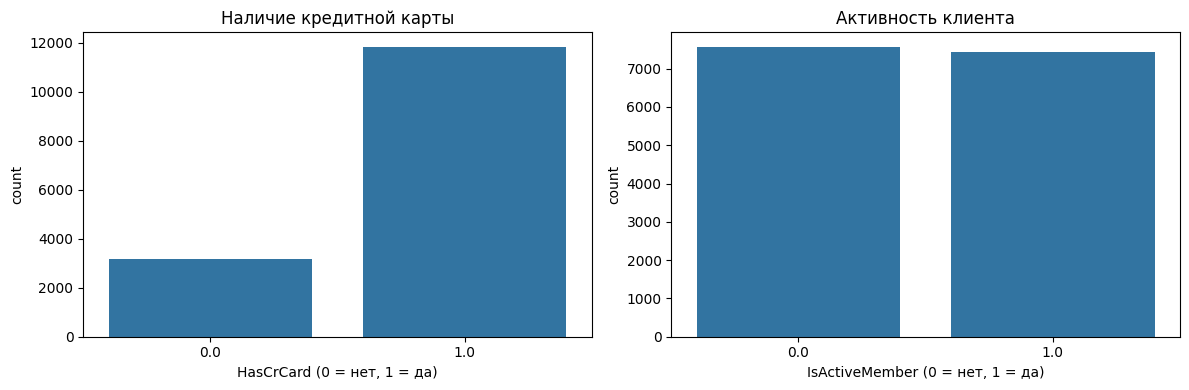

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train_raw, x="HasCrCard", ax=axes[0])
axes[0].set_title("Наличие кредитной карты")
axes[0].set_xlabel("HasCrCard (0 = нет, 1 = да)")

sns.countplot(data=train_raw, x="IsActiveMember", ax=axes[1])
axes[1].set_title("Активность клиента")
axes[1].set_xlabel("IsActiveMember (0 = нет, 1 = да)")

plt.tight_layout()
plt.show()

# Категориальные признаки и фамилии

Удаляем фамилии. Смотрим на `Geography` и `Gender` кодировать буду потом

In [22]:
print("топ 20 фамилий в train:")

display(train_raw["Surname"].value_counts().head(20))

print("Geography:", train_raw["Geography"].unique())
print("Gender:", train_raw["Gender"].unique())

топ 20 фамилий в train:


Surname
Ch'iu       283
Ch'ien      233
Ch'ang      232
T'ien       206
Hsia        185
H?          169
Chiu        167
Hs?         167
Maclean     158
Ch'eng      150
Shih        149
Ts'ui       142
Ch'in       138
Hsueh       134
Nwankwo     127
Mazzanti    124
Kao         123
Chukwudi    122
Tuan        118
Manna       114
Name: count, dtype: int64

Geography: ['Germany' 'France' 'Spain']
Gender: ['Male' 'Female']


In [26]:
train_df = train_raw.drop(columns=["Surname"]).copy()
test_df = test_raw.drop(columns=["Surname"]).copy()


print("Train after cleaning:")
print(train_df.columns.tolist())

print("\nTest after cleaning:")
print(test_df.columns.tolist())


Train after cleaning:
['id', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Test after cleaning:
['id', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


# Сохраняем обработанные данные 

In [27]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

train_output = PROCESSED_DATA_DIR / "train_cleaned.csv"
test_output = PROCESSED_DATA_DIR / "test_cleaned.csv"

train_df.to_csv(train_output, index=False)
test_df.to_csv(test_output, index=False)

print(f"Saved: {train_output} — {train_df.shape}")
print(f"Saved: {test_output} — {test_df.shape}")

Saved: data/processed/train_cleaned.csv — (15000, 13)
Saved: data/processed/test_cleaned.csv — (10000, 12)
